## Title: Predicting Future Amazon Purchases Using Demographics and Purchase Histories

### Team
1. Name: Alexa Lotano - POC <br>
    GitHub ID: alexa-lotano
2. Name: Shahaan Khan - POC <br>
    GitHub ID: ShahaanK
3. Name: Ben Euto - POC <br>
    GitHub ID: bene01-git

### Overview - NOT DONE

This section will contain an overview of your current objectives.  It will _briefly_ answer the following questions from [Heilmeier's catechism](https://www.darpa.mil/work-with-us/heilmeier-catechism).

- What are you trying to do? Articulate your objectives using absolutely no jargon.
- What is new in your approach and why do you think it will be successful?  (be brief here, you can expand more later!)
- Who cares? If you are successful, what difference will it make? Importantly, who is your primary stakeholder, and what specific need are you addressing?

It is quite possible that these have changed since your last submission.  If so, please indicate what has changed and why.

### Data - NOT DONE

The data used in our project is titled "Open e-commerce 1.0: Five years of crowdsourced U.S. Amazon purchase histories with user demographics" and can be found at the following link:
https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY

Harvard Dataverse is an open source data repository owned and operated by Harvard University. The dataset we will be using involves crowdsourced data obtained through surveys, meaning data was provided voluntarily by subjects. The data does not contain any uniquely identifiable information of survey participants.

The dataset contains information regarding participants' past Amazon purchases, as well as demographic and personal information. Data was collected from 5,027 unique survey participants and contains approximately 1,050,000 Amazon purchases.

Due to the extremely large file sizes, we sampled 800 survey responses and will be analyzing only the Amazon purchases linked to these survey respondants. After cleaning and transforming the dataset, our data represents 157,026 Amazon purchases.

[insert notable discoveries from EDA - distributions, etc.]



Due to the extremely large file sizes, we sampled 800 survey responses and will be analyzing only the Amazon purchases linked to these survey respondants. After cleaning and transforming the dataset, our data represents 157,026 Amazon purchases. The cleaning and transformation process is described below, in the Preprocessing section. 

Once the data was cleaned, we split the data into training and testing sets based on year, scaled the data, and performed PCA to reduce the dimensionality of the data. The reduced data is visualized below. Note, this data uses the "Category" value as the target. However, we also anticipate using the "Title" and "ASIN/ISBN (Product Code)" variables as targets in future models. Since these variables are highly linked to category (i.e., the product title and cde directly determine the category), these columns were removed before visualizing and modeling the data. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/workspaces/group-project-bas-team/data/cleaned_data.csv")

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)

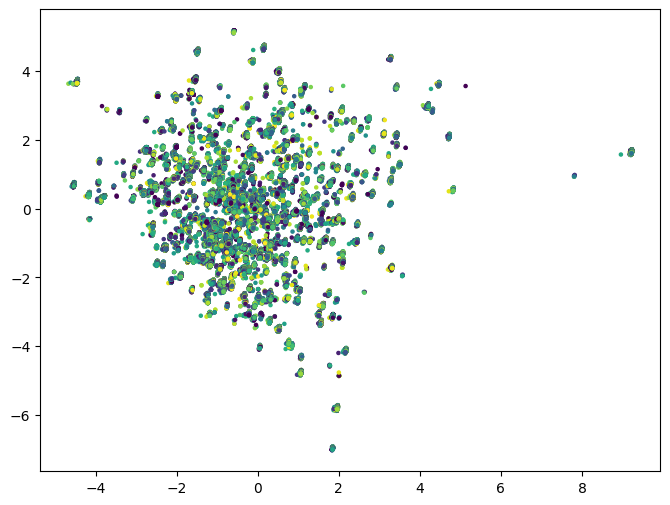

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = data_limited_train.drop('Category', axis=1)
y_train = data_limited_train['Category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('Category', axis=1)
y_test = data_limited_test['Category']
X_test_scaled = StandardScaler().fit_transform(X_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=5)
plt.show()

We then identified the number of principal components needed to explain 95% of the variance in the data, and again reduced the data using PCA with that number of components.

In [5]:
import numpy as np

pca_scree = PCA()
X_pca_scree = pca_scree.fit_transform(X_train_scaled)

variance_explained = pca_scree.explained_variance_ratio_

threshold = 0.95
n_components = np.argmax(variance_explained.cumsum() >= threshold) + 1
print(f"Number of components for {threshold*100}% variance: {n_components}")

pca = PCA(n_components=n_components)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.fit_transform(X_test_scaled)

Number of components for 95.0% variance: 93


Beyond PCA, we also attempted to reduce the dimensionality of our data using UMAP. Both the PCA reduced and UMAP reduced data were tested using a k-nearest neighbor classifier. The PCA reduced data outperformed the UMAP data, leading us to use our PCA reduced data in our modeling efforts.

We also determined that factor analysis was not suitable for our data, with an extremely low KMO value.

### Preprocessing

After conducting exploratory data analysis on both the Amazon purchase data and the survey data, we merged the datasets on the shared "Survey ResponseID" column, effectively linking each Amazon purchase to the customer who made the purchase. Before merging, however, the Amazon purchase data had over 1 million rows. To make our data more manageable and easier to model, we sampled 800 survey responses from the survey dataset, and merged these responses with the Amazon purchase dataset using "how=inner" in the merge function, leaving us with the Amazon purchases for only 800 surveyed customers.

The resulting data had missing values in the "Shipping Address State", "Title", "ASIN/ISBN (Product Code)", "Category", and "Q-life-changes" columns. We decided not to impute these using traditional methods such as mean or mode imputation, as we felt these imputations may not be reliable since there are so many unique values in our dataset. Instead, we used the ASIN/ISBN codes to create dictionaries of the corresponding titles and categories of the products and use thse dictionaries to fill in missing titles and categories where an ASIN/ISBN code was present. The following code shows an example of this transformation.

In [ ]:
# Note: The code in this section will not run, as we did not load the original dataset in this file
# These code snippets serve only as examples of the code we ran to clean and transform our data

codes = data[['ASIN/ISBN (Product Code)', 'Title']].drop_duplicates().dropna()
codes_dict = codes.set_index('ASIN/ISBN (Product Code)')['Title'].to_dict()
data['Title'] = data['ASIN/ISBN (Product Code)'].map(codes_dict)

The NA values in the "Q-life-changes" column appeared to represent rows where the consumer did not have any significant life changes to report at the time of response. As such, we filled the missing values in this column with "None" using the following code:

In [ ]:
data['Q-life-changes'] = data['Q-life-changes'].fillna('None')

Finally, any remaining rows with missing data were removed from the dataframe, reducing the number of rows from 171,997 to 157,026.

Next, we renamed 22 columns in the dataframe to remove redundant information, such as the letter "Q" in the survey response columns. We also dropped columns that we will not be using to predict purchase behavior, namely "Survey ResponseID", "sell-YOUR-data", "sell-consumer-data", "small-biz-use", "census-use", and "research society".

We then split the "Order Date" column into order month, day, and year columns and dropped the original column.

Once the data was fully cleaned as described above, we began encoding the data in order to visualize and eventually build models with it. We began by ordinal encoding the variables that have a natural order. Since the order of such variables may not have been alphabetical, we manually created mappings for these variables, then looped through the encoding process for each applicable column using these mappings, as demonstated below.

In [ ]:
ordinal_mappings = {
    'age': {
        '18 - 24 years': 1,
        '25 - 34 years': 2,
        '35 - 44 years': 3,
        '45 - 54 years': 4,
        '55 - 64 years': 5,
        '65 and older': 6
    },
    'education': {
        'Prefer not to say': 0,
        'Some high school or less': 1,
        'High school diploma or GED': 2,
        "Bachelor's degree": 3,
        'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)': 4
    },
    'income': {
        'Prefer not to say': 0,
        'Less than $25,000': 1,
        '$25,000 - $49,999': 2,
        '$50,000 - $74,999': 3,
        '$75,000 - $99,999': 4,
        '$100,000 - $149,999': 5,
        '$150,000 or more': 6
    },
    'howmany': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'hh-size': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'how-oft': {
        'Less than 5 times per month': 1,
        '5 - 10 times per month': 2,
        'More than 10 times per month': 3
    }
}

for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)
    unmapped = data[col].isna().sum()
    if unmapped > 0:
        print(f"Warning: {unmapped} unmapped values in '{col}' — check category strings match exactly")

Next, we binary encoded the "hispanic" variable, as this was the only column in our dataset that only had two values ("Yes" or "No"). The following code was used:

In [ ]:
yes_no_map = {'Yes': 1, 'No': 0}

data['hispanic'] = data['hispanic'].map(yes_no_map)

Finally, we one-hot encoded the remaining categorical variables, which all had more than two unique values. We also removed a single resulting column for each variable to prevent multicollinearity, since the value of a single one-hot encoded column can be derived from the values of the other columns representing that variable. Finally, we combined the one-hot encoded columns with the original dataframe, then removed the original columns that are now represented as one-hot encoded columns. This process was completed using the following code:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

data_one_hot = encoder.fit_transform(data[['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes']])
df_one_hot = pd.DataFrame(data_one_hot, columns=encoder\
                          .get_feature_names_out(['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                                    'wheelchair', 'Shipping Address State', 'gender',\
                                                    'sexual-orientation', 'state', 'race', 'life-changes']))

df_one_hot = df_one_hot.drop(columns=['cigarettes_Prefer not to say', 'alcohol_Prefer not to say', \
                                      'marijuana_Prefer not to say', 'diabetes_Prefer not to say', \
                                        'wheelchair_Prefer not to say', 'Shipping Address State_HI', \
                                        'gender_Prefer not to say', 'sexual-orientation_prefer not to say', \
                                        'state_Alaska', 'race_Other', 'life-changes_None'])

df_combined = pd.concat([data, df_one_hot], axis=1)
df_combined = df_combined.drop(columns=['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes'])

Finally, we identified three columns that we may use as target columns. These columns are "Title", "ASIN/ISBN (Product Code)", and "Category". All three of these columns were label encoded, as demonstrated below.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

target_cols = ['Title', 'ASIN/ISBN (Product Code)', 'Category']

for col in target_cols:
    df_combined[col] = le.fit_transform(df_combined[col].astype(str))

The final dataframe consists of 157,026 rows and 156 columns.

Once our dataset was completely cleaned and transformed as described above, we saved the cleaned dataframe to a csv file in our "data" folder using the following code:

In [ ]:
df_combined.to_csv('/workspaces/group-project-bas-team/data/cleaned_data.csv', index=False)

Saving the dataset allows us to easily read our data into new files so we do not need to repeat the cleaning process in future files.

### Modeling

We began modeling the data using a simple K-nearest neighbors classifier. The resulting accuracy was extremely low at only 0.015 or 1.5%. This may indicate that demographic information is likely not enough to determine the types of purchases made by Amazon customers. We expect to be able to improve our model performance greatly when we begin analyzing sequential buying patterns and predicting future purchases based on previous purchases.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()
knn.fit(X_train_reduced, y_train)
pred = knn.predict(X_test_reduced)

accuracy_score(y_test, pred)

0.015010029743376911

### Problems & Challenges

The main challenge we are facing at this point is the processing time of our models. Even with relatively simple models such as decision tree classifiers and random forest classifiers, each model is running very slowly. We anticipate this problem getting worse as the complexity of our models increases. If we continue facing this challenge, we may need to take a smaller sample of the original data and rerun our data preparation and dimensionality reduction steps, or use fewer principal components when modeling the data.

### Next steps - NOT DONE

Tell me where you are going with the project; what are the next steps, and when do you think they will be done?  Include rough dates! 